In [1]:
from IPython.display import clear_output
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from LatentEvolution.zapbench_data import load_sparse_activity
from LatentEvolution.zapbench_config import CONDITIONS, DataConfig, DataSplit
from LatentEvolution.mlp import MLP, MLPParams

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu")
print(f"using device: {device}")
torch.set_float32_matmul_precision('high')


using device: mps


## load data

In [2]:
BIN_SIZE_MS = 100.0  # 100ms bins


In [3]:
# load all training conditions
# data_cfg = DataConfig()
data_cfg = DataConfig(
    traces_path="/Users/kumarv/zapbench-data/traces",
    ephys_path="/Users/kumarv/zapbench-data/ephys.zarr",
    bin_size_ms=BIN_SIZE_MS
)
data_split = DataSplit()

# get train and val ranges
train_ranges = data_split.get_ranges("train")
val_ranges = data_split.get_ranges("val")

print("training conditions:")
for name, start, end in train_ranges:
    print(f"  {name}: bins {start}-{end} ({end-start} frames)")

print("\nvalidation conditions:")
for name, start, end in val_ranges:
    print(f"  {name}: bins {start}-{end} ({end-start} frames)")

training conditions:
  gain: bins 1-454 (453 frames)
  dots: bins 650-1890 (1240 frames)
  flash: bins 2423-2881 (458 frames)
  turning: bins 3736-4653 (917 frames)
  position: bins 5048-5460 (412 frames)
  open_loop: bins 5639-6327 (688 frames)
  rotation: bins 6624-7082 (458 frames)
  dark: bins 7280-7698 (418 frames)

validation conditions:
  gain: bins 454-519 (65 frames)
  dots: bins 1890-2067 (177 frames)
  flash: bins 2881-2946 (65 frames)
  turning: bins 4653-4784 (131 frames)
  position: bins 5460-5519 (59 frames)
  open_loop: bins 6327-6425 (98 frames)
  rotation: bins 7082-7147 (65 frames)
  dark: bins 7698-7758 (60 frames)


In [4]:
# load data for a list of ranges, concatenate along time
def load_ranges(ranges, bin_size_ms):
    """load and concatenate data from multiple ranges.

    returns: obs_times, obs_vals, counts, total_bins, range_boundaries
    """
    all_obs_times = []
    all_obs_vals = []
    range_boundaries = [0]
    total_bins = 0

    for name, start, end in ranges:
        # load this range
        obs_times, obs_vals, counts, num_bins = load_sparse_activity(
            traces_path=data_cfg.traces_path,
            ephys_path=data_cfg.ephys_path,
            bin_size_ms=bin_size_ms,
            time_slice=slice(start, end),
        )

        # offset times by current total
        obs_times_offset = obs_times + total_bins
        all_obs_times.append(obs_times_offset)
        all_obs_vals.append(obs_vals)

        total_bins += num_bins
        range_boundaries.append(total_bins)
        print(f"  loaded {name}: {num_bins} bins, total now {total_bins}")

    # concatenate along observation dimension (K)
    obs_times_cat = torch.cat(all_obs_times, dim=1)
    obs_vals_cat = torch.cat(all_obs_vals, dim=1)
    counts_cat = torch.tensor([obs_times_cat.shape[1]] * obs_times_cat.shape[0])

    return obs_times_cat, obs_vals_cat, counts_cat, total_bins, range_boundaries

print("loading training data...")
train_obs_times, train_obs_vals, train_counts, train_T, train_boundaries = load_ranges(
    train_ranges, BIN_SIZE_MS
)
N_full = train_obs_times.shape[0]
print(f"\ntotal: {N_full} neurons, {train_T} bins, {train_obs_times.shape[1]} obs per neuron")

loading training data...
  loaded gain: 4140 bins, total now 4140
  loaded dots: 11333 bins, total now 15473
  loaded flash: 4186 bins, total now 19659
  loaded turning: 8381 bins, total now 28040
  loaded position: 3766 bins, total now 31806
  loaded open_loop: 6288 bins, total now 38094
  loaded rotation: 4186 bins, total now 42280
  loaded dark: 3820 bins, total now 46100

total: 71721 neurons, 46100 bins, 5044 obs per neuron


In [5]:
condition_index = 0
bin_low = train_boundaries[condition_index]
bin_high = train_boundaries[condition_index+1]

obs_vals = train_obs_vals[:, bin_low:bin_high]
obs_times = train_obs_times[:, bin_low:bin_high]

In [6]:
obs_times.shape

torch.Size([71721, 4140])

low  CV neurons  (<p10):    7,172
med  CV neurons  (p40-p60): 14,345
high CV neurons  (>=p99):   718


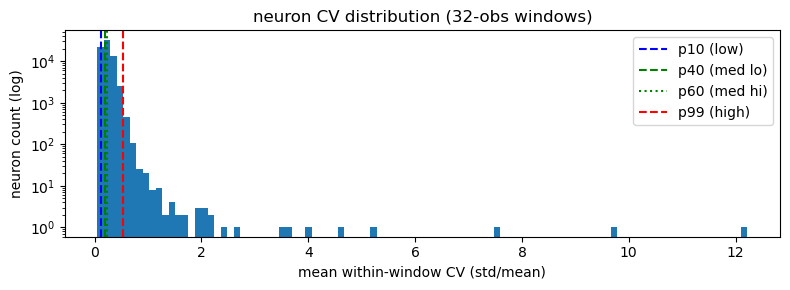

In [46]:
# compute per-neuron CV (std/mean) within 32-observation windows
WINDOW = 32

N, K_obs = obs_vals.shape
num_windows = K_obs // WINDOW

# reshape into (N, num_windows, WINDOW)
obs_w = obs_vals[:, :num_windows * WINDOW].reshape(N, num_windows, WINDOW)

mean_w = obs_w.mean(dim=2)          # (N, num_windows)
std_w  = obs_w.std(dim=2)           # (N, num_windows)
cv_w   = std_w / mean_w
cv_w[mean_w <= 0] = float('nan')

neuron_cv = torch.nanmean(cv_w, dim=1)  # (N,)

valid_cv = neuron_cv[torch.isfinite(neuron_cv)]
p_low    = torch.quantile(valid_cv, 0.10)
p_med_lo = torch.quantile(valid_cv, 0.40)
p_med_hi = torch.quantile(valid_cv, 0.60)
p_high   = torch.quantile(valid_cv, 0.99)

low_neurons  = torch.where(neuron_cv < p_low)[0]
med_neurons  = torch.where((neuron_cv >= p_med_lo) & (neuron_cv <= p_med_hi))[0]
high_neurons = torch.where(neuron_cv >= p_high)[0]

print(f"low  CV neurons  (<p10):    {len(low_neurons):,}")
print(f"med  CV neurons  (p40-p60): {len(med_neurons):,}")
print(f"high CV neurons  (>=p99):   {len(high_neurons):,}")

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(valid_cv.cpu().numpy(), bins=100, log=True)
ax.axvline(p_low.item(),    color='blue',  linestyle='--', label='p10 (low)')
ax.axvline(p_med_lo.item(), color='green', linestyle='--', label='p40 (med lo)')
ax.axvline(p_med_hi.item(), color='green', linestyle=':',  label='p60 (med hi)')
ax.axvline(p_high.item(),   color='red',   linestyle='--', label='p99 (high)')
ax.set_xlabel('mean within-window CV (std/mean)')
ax.set_ylabel('neuron count (log)')
ax.set_title(f'neuron CV distribution ({WINDOW}-obs windows)')
ax.legend()
plt.tight_layout()
plt.show()


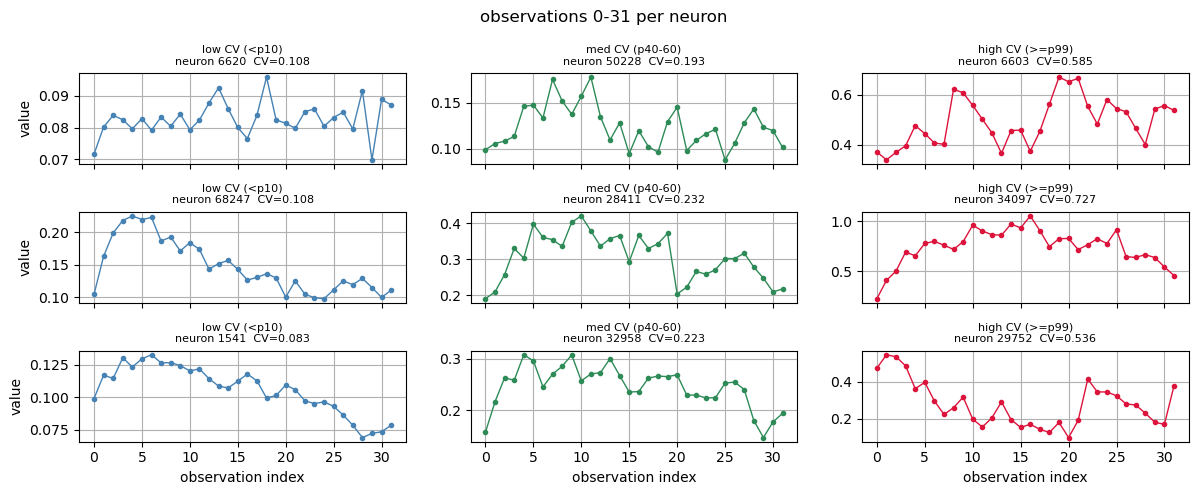

In [47]:
# plot 3 random neurons from each CV category, 32 consecutive observations
OBS_START = 0
N_PICK = 3
SEED = 42

rng = torch.Generator()
rng.manual_seed(SEED)

sample_low  = low_neurons[torch.randperm(len(low_neurons),  generator=rng)[:N_PICK]]
sample_med  = med_neurons[torch.randperm(len(med_neurons),  generator=rng)[:N_PICK]]
sample_high = high_neurons[torch.randperm(len(high_neurons), generator=rng)[:N_PICK]]

fig, axes = plt.subplots(N_PICK, 3, figsize=(12, 5), sharey=False, sharex=True)

for col, (label, neurons, color) in enumerate([
    ('low CV (<p10)',   sample_low,  'steelblue'),
    ('med CV (p40-60)', sample_med,  'seagreen'),
    ('high CV (>=p99)', sample_high, 'crimson'),
]):
    for row, nid in enumerate(neurons):
        ax = axes[row, col]
        vals = obs_vals[nid, OBS_START:OBS_START + 32].cpu()
        ax.plot(vals.numpy(), color=color, marker='o', markersize=3, linewidth=1)
        ax.set_title(f'{label}\nneuron {nid.item()}  CV={neuron_cv[nid].item():.3f}', fontsize=8)
        if row == N_PICK - 1:
            ax.set_xlabel('observation index')
        if col == 0:
            ax.set_ylabel('value')
        ax.grid(True)

plt.suptitle(f'observations {OBS_START}-{OBS_START+31} per neuron')
plt.tight_layout()
plt.show()


In [71]:
# --- hyperparameters ---
L_DIM = 64

N = obs_vals.shape[0]

# --- evolver: z[t] -> z[t+1] ---
evolver = MLP(MLPParams(
    num_input_dims=L_DIM,
    num_output_dims=L_DIM,
    num_hidden_layers=1,
    num_hidden_units=L_DIM,
    activation='Tanh',
    use_batch_norm=False,
)).to(device)

# --- linear decoder initialised via truncated SVD of obs_vals ---
# factorise obs_vals ≈ U S Vt  (no centering)
# W_dec = U  (N, L_DIM)   decoder directions in neuron space
U, S, V = torch.svd_lowrank(obs_vals.float(), q=L_DIM)  # U:(N,L), S:(L,), V:(K,L)
W_dec = nn.Parameter(U.to(device))                      # (N, L_DIM), trainable, init from SVD
b_dec = nn.Parameter(torch.zeros(N, device=device))     # (N,)

print(f"singular values: {S.tolist()}")

def get_window(k_start):
    """extract a WINDOW-obs window.

    returns:
        w_vals:   (N, WINDOW)  observed values
        obs_idx:  (N, WINDOW)  indices into the T_window rollout where each
                               observation falls, i.e. x_hat[n, obs_idx[n, k]]
                               should match w_vals[n, k]
        T_window: int          number of evolver steps needed
    """
    w_vals  = obs_vals[:, k_start:k_start + WINDOW]   # (N, WINDOW)
    w_times = obs_times[:, k_start:k_start + WINDOW]  # (N, WINDOW)
    t_min   = int(w_times.min().item())
    t_max   = int(w_times.max().item())
    T_window = t_max - t_min + 1
    obs_idx  = (w_times - t_min).long()               # (N, WINDOW), in [0, T_window)
    return w_vals, obs_idx, T_window

def rollout(z0, T):
    """evolve z0 for T steps: returns z of shape (T, L_DIM)."""
    zs = [z0]
    z = z0
    for _ in range(T - 1):
        z = z + evolver(z.unsqueeze(0)).squeeze(0)
        zs.append(z)
    return torch.stack(zs, dim=0)  # (T, L_DIM)

def decode(z):
    """linear decode: z (T, L_DIM) -> x_hat (N, T)."""
    return (z @ W_dec.T + b_dec).T  # (N, T)

print(f"W_dec shape: {W_dec.shape}  singular values: {S.tolist()}")

def plot_reconstruction(k_start=0, title=''):
    """plot z_bank decoded reconstruction vs raw (phase 1 quality)."""
    w_vals_p  = obs_vals[:, k_start:k_start + WINDOW]          # (N, WINDOW)
    w_times_p = obs_times[:, k_start:k_start + WINDOW]         # (N, WINDOW)
    with torch.no_grad():
        z_at_obs = z_bank[w_times_p.long().to(device)]          # (N, WINDOW, L_DIM)
        x_pred   = (z_at_obs * W_dec.unsqueeze(1)).sum(-1) + b_dec.unsqueeze(1)  # (N, WINDOW)

    fig, axes = plt.subplots(N_PICK, 3, figsize=(12, 5), sharey=False)
    for col, (label, neurons, color) in enumerate([
        ('low CV (<p10)',   sample_low,  'steelblue'),
        ('med CV (p40-60)', sample_med,  'seagreen'),
        ('high CV (>=p99)', sample_high, 'crimson'),
    ]):
        for row, nid in enumerate(neurons):
            ax = axes[row, col]
            raw  = w_vals_p[nid].cpu().numpy()
            pred = x_pred[nid].cpu().numpy()
            ax.plot(raw,  color=color,   marker='o', markersize=3, linewidth=1, label='raw')
            ax.plot(pred, color='black', marker='x', markersize=3, linewidth=1,
                    linestyle='--', label='recon')
            ymin, ymax = raw.min(), raw.max()
            margin = (ymax - ymin) * 0.1 or 0.1
            ax.set_ylim(ymin - margin, ymax + margin)
            ax.set_title(f'{label}\nneuron {nid.item()}  CV={neuron_cv[nid].item():.3f}', fontsize=8)
            if row == N_PICK - 1:
                ax.set_xlabel('observation index')
            if col == 0:
                ax.set_ylabel('value')
            if row == 0 and col == 0:
                ax.legend(fontsize=7)
    plt.suptitle(title or f'reconstruction from z_bank  (window k_start={k_start})')
    plt.tight_layout()
    plt.show()


def plot_rollout(k_start=0, title=''):
    """roll out from z_bank[t0] using evolver, decode, compare to raw (phase 2 quality)."""
    w_vals_p  = obs_vals[:, k_start:k_start + WINDOW]          # (N, WINDOW)
    w_times_p = obs_times[:, k_start:k_start + WINDOW]         # (N, WINDOW)
    t0       = int(w_times_p.min().item())
    T_window = int(w_times_p.max().item()) - t0 + 1
    obs_idx  = (w_times_p - t0).long()                         # (N, WINDOW)

    with torch.no_grad():
        z0_t = z_bank[t0]                                                  # (L_DIM,)
        z    = rollout(z0_t, T_window)                         # (T_window, L_DIM)
        x_hat = decode(z)                                      # (N, T_window)
        x_pred = x_hat[torch.arange(N, device=device).unsqueeze(1),
                        obs_idx.to(device)]                    # (N, WINDOW)

    fig, axes = plt.subplots(N_PICK, 3, figsize=(12, 5), sharey=False)
    for col, (label, neurons, color) in enumerate([
        ('low CV (<p10)',   sample_low,  'steelblue'),
        ('med CV (p40-60)', sample_med,  'seagreen'),
        ('high CV (>=p99)', sample_high, 'crimson'),
    ]):
        for row, nid in enumerate(neurons):
            ax = axes[row, col]
            raw  = w_vals_p[nid].cpu().numpy()
            pred = x_pred[nid].cpu().numpy()
            ax.plot(raw,  color=color,   marker='o', markersize=3, linewidth=1, label='raw')
            ax.plot(pred, color='black', marker='x', markersize=3, linewidth=1,
                    linestyle='--', label='rollout')
            ymin, ymax = raw.min(), raw.max()
            margin = (ymax - ymin) * 0.1 or 0.1
            ax.set_ylim(ymin - margin, ymax + margin)
            ax.set_title(f'{label}\nneuron {nid.item()}  CV={neuron_cv[nid].item():.3f}', fontsize=8)
            if row == N_PICK - 1:
                ax.set_xlabel('observation index')
            if col == 0:
                ax.set_ylabel('value')
            if row == 0 and col == 0:
                ax.legend(fontsize=7)
    plt.suptitle(title or f'evolver rollout from t0={t0}  (window k_start={k_start})')
    plt.tight_layout()
    plt.show()


singular values: [2139.36572265625, 409.69586181640625, 316.2259826660156, 246.19503784179688, 200.77210998535156, 172.706787109375, 158.212646484375, 146.19515991210938, 143.07676696777344, 140.9730682373047, 137.61978149414062, 136.5732879638672, 126.74278259277344, 123.88716125488281, 115.72822570800781, 111.93482971191406, 111.62330627441406, 110.25215148925781, 106.11094665527344, 102.54550170898438, 100.43377685546875, 98.08744812011719, 93.2879409790039, 90.72427368164062, 87.75325775146484, 85.11518859863281, 82.15755462646484, 81.54521942138672, 79.70252990722656, 78.73543548583984, 77.49275970458984, 76.25150299072266, 75.4423828125, 74.14244079589844, 72.56131744384766, 71.06111145019531, 70.24419403076172, 68.65667724609375, 66.68344116210938, 66.25919342041016, 65.02098083496094, 63.97579574584961, 63.4141845703125, 62.65596389770508, 60.904693603515625, 60.46683883666992, 58.42393493652344, 57.624046325683594, 57.16728973388672, 57.01374435424805, 55.16925048828125, 55.05

In [74]:
# --- two-phase training ---
LR_PHASE1  = 1e-3
LR_PHASE2  = 1e-3
ROLLOUT    = 100
BATCH_SIZE = 32   # for phase 2
N_PHASE1_EPOCHS = 10
N_PHASE2_EPOCHS = 1
TV_WEIGHT  = 0.1  # smoothness regularization on z_bank
T = int(obs_times.max().item()) + 1

# z_bank: one latent per time bin
z_bank = nn.Parameter(torch.zeros(T, L_DIM, device=device))
nn.init.normal_(z_bank, std=0.01)

# init evolver output to ~0: zero last linear layer
with torch.no_grad():
    last_linear = [m for m in evolver.modules() if isinstance(m, nn.Linear)][-1]
    last_linear.weight.zero_()
    last_linear.bias.zero_()


  epoch 10/10  avg loss=1.2583


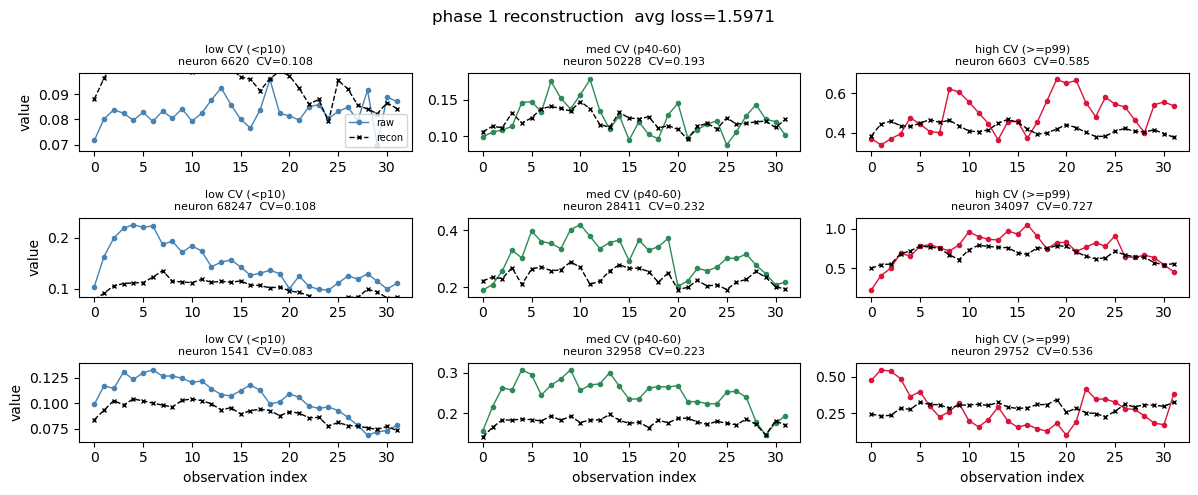

phase 1 done  avg loss=1.5971


In [75]:

num_windows_per_epoch = obs_vals.shape[1] // WINDOW

# ── phase 1: reconstruct obs_vals from z_bank ──────────────────────────────
print("phase 1: reconstruction")
opt1 = torch.optim.Adam(
    [z_bank, W_dec, b_dec], lr=LR_PHASE1
)
p1_losses = []
for epoch in range(N_PHASE1_EPOCHS):
    for k in range(num_windows_per_epoch):
        w_vals_k  = obs_vals[:, k * WINDOW:(k + 1) * WINDOW].to(device)         # (N, WINDOW)
        w_times_k = obs_times[:, k * WINDOW:(k + 1) * WINDOW].long().to(device)  # (N, WINDOW)

        z_at_obs = z_bank[w_times_k]                                             # (N, WINDOW, L_DIM)
        x_pred   = (z_at_obs * W_dec.unsqueeze(1)).sum(-1) + b_dec.unsqueeze(1)  # (N, WINDOW)

        # normalize by per-neuron within-window std; skip constant neurons
        std_k = w_vals_k.std(dim=1)                                              # (N,)
        valid = std_k > 1e-3
        if not valid.any():
            continue
        recon_loss = (((x_pred[valid] - w_vals_k[valid]) / std_k[valid].unsqueeze(1)) ** 2).mean()

        # tv regularization: penalize large jumps between adjacent time bins
        tv_loss = ((z_bank[1:] - z_bank[:-1]) ** 2).mean()

        loss = recon_loss + TV_WEIGHT * tv_loss

        opt1.zero_grad()
        loss.backward()
        opt1.step()
        p1_losses.append(loss.item())


    avg = sum(p1_losses[-num_windows_per_epoch:]) / max(len(p1_losses[-num_windows_per_epoch:]), 1)
    clear_output(wait=True)
    print(f"  epoch {epoch+1}/{N_PHASE1_EPOCHS}  avg loss={avg:.4f}")
    plot_reconstruction(title=f'phase 1 reconstruction  avg loss={sum(p1_losses)/len(p1_losses):.4f}')


print(f"phase 1 done  avg loss={sum(p1_losses)/len(p1_losses):.4f}")


  epoch 10/10  avg loss=1.0671


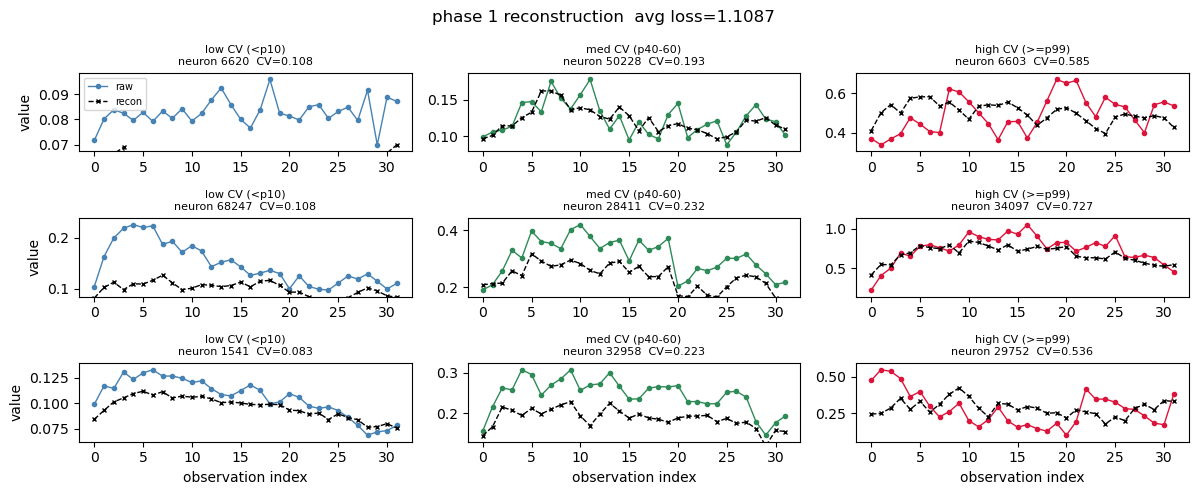

phase 1 done  avg loss=1.1087


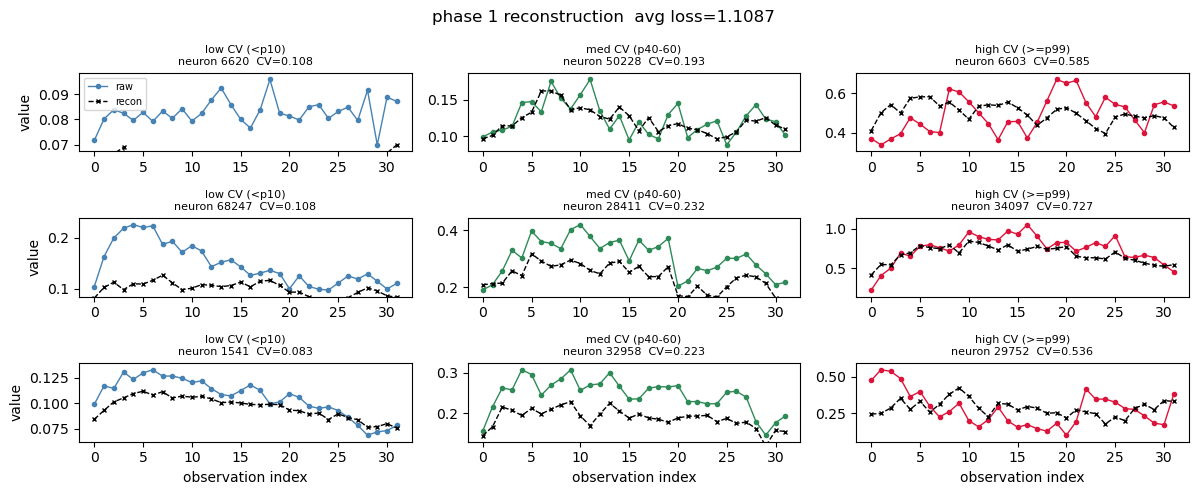

In [ ]:

# ── phase 2: train evolver to match z_bank trajectory ──────────────────────
print("phase 2: evolver")
opt2 = torch.optim.Adam(evolver.parameters(), lr=LR_PHASE2)
p2_losses = []

valid_starts = T - ROLLOUT

for epoch in range(N_PHASE2_EPOCHS):
    starts = torch.randperm(valid_starts)
    for i in range(0, valid_starts, BATCH_SIZE):
        t_batch = starts[i:i + BATCH_SIZE].to(device)               # (B,)
        z_start = z_bank[t_batch].detach()                           # (B, L_DIM)

        # batched rollout
        zs = [z_start]
        z  = z_start
        for _ in range(ROLLOUT - 1):
            z = z + evolver(z)
            zs.append(z)
        z_pred = torch.stack(zs, dim=0)                              # (ROLLOUT, B, L_DIM)

        # targets from z_bank: for each t in t_batch, gather t..t+ROLLOUT
        t_idx = t_batch.unsqueeze(0) + torch.arange(ROLLOUT, device=device).unsqueeze(1)
        z_target = z_bank[t_idx].detach()                            # (ROLLOUT, B, L_DIM)

        loss = F.mse_loss(z_pred[1:], z_target[1:])

        opt2.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(evolver.parameters(), max_norm=1.0)
        opt2.step()
        p2_losses.append(loss.item())

    print(f"  epoch {epoch+1}/{N_PHASE2_EPOCHS}  loss={p2_losses[-1]:.4f}")

print(f"phase 2 done  avg loss={sum(p2_losses)/len(p2_losses):.4f}")
plot_rollout(title=f'phase 2 evolver  avg loss={sum(p2_losses)/len(p2_losses):.4f}')


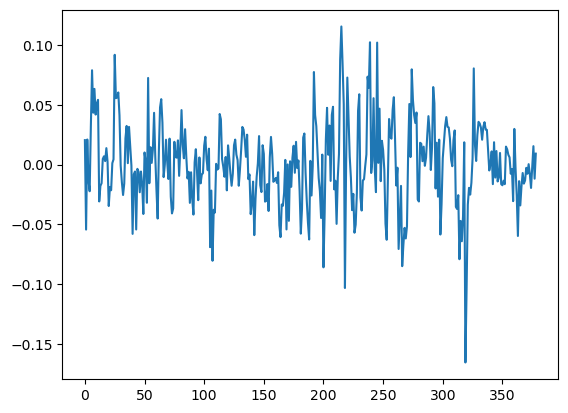

In [70]:
plt.plot(z_bank[::100, 3].detach().cpu())

phase 2: evolver
  epoch 1/5  loss=0.0010
  epoch 2/5  loss=0.0008
  epoch 3/5  loss=0.0009
  epoch 4/5  loss=0.0010
  epoch 5/5  loss=0.0009
phase 2 done  avg loss=0.0010


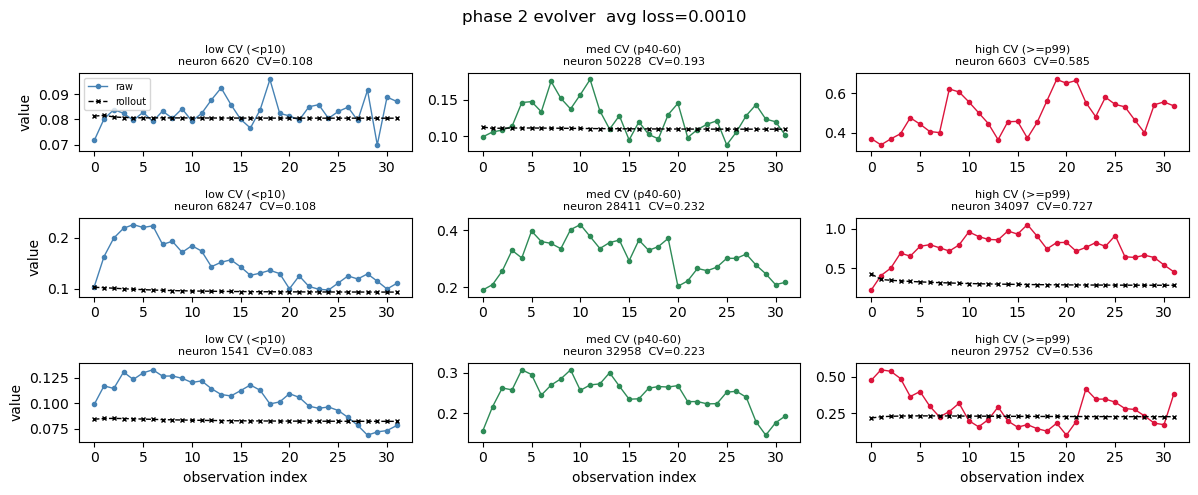

In [59]:
N_PHASE2_EPOCHS = 5
# ── phase 2: train evolver to match z_bank trajectory ──────────────────────
print("phase 2: evolver")
opt2 = torch.optim.Adam(evolver.parameters(), lr=LR_PHASE2)
p2_losses = []

valid_starts = T - ROLLOUT

for epoch in range(N_PHASE2_EPOCHS):
    starts = torch.randperm(valid_starts)
    for i in range(0, valid_starts, BATCH_SIZE):
        t_batch = starts[i:i + BATCH_SIZE].to(device)               # (B,)
        z_start = z_bank[t_batch].detach()                           # (B, L_DIM)

        # batched rollout
        zs = [z_start]
        z  = z_start
        for _ in range(ROLLOUT - 1):
            z = z + evolver(z)
            zs.append(z)
        z_pred = torch.stack(zs, dim=0)                              # (ROLLOUT, B, L_DIM)

        # targets from z_bank: for each t in t_batch, gather t..t+ROLLOUT
        t_idx = t_batch.unsqueeze(0) + torch.arange(ROLLOUT, device=device).unsqueeze(1)
        z_target = z_bank[t_idx].detach()                            # (ROLLOUT, B, L_DIM)

        loss = F.mse_loss(z_pred[1:], z_target[1:])

        opt2.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(evolver.parameters(), max_norm=1.0)
        opt2.step()
        p2_losses.append(loss.item())

    print(f"  epoch {epoch+1}/{N_PHASE2_EPOCHS}  loss={p2_losses[-1]:.4f}", flush=True)

print(f"phase 2 done  avg loss={sum(p2_losses)/len(p2_losses):.4f}")
plot_rollout(title=f'phase 2 evolver  avg loss={sum(p2_losses)/len(p2_losses):.4f}')

In [ ]:
plot_reconstruction()
plot_rollout()
